# Методы классификации: kNN, наивный Байес, деревья и ансамбли

## Содержание

0. Подготовка среды и подключение Weights & Biases
1. Данные и протокол сравнения моделей
2. Метод ближайших соседей (kNN)
3. Наивный байесовский классификатор
4. Деревья решений и ансамбли
5. Сравнение моделей
6. Практикум

На третьем занятии мы разобрали логистическую регрессию и метрики качества. Теперь познакомимся с другими семействами моделей классификации и научимся **честно их сравнивать**:

- **kNN** — «ленивое» обучение на расстояниях;
- **наивный Байес** — вероятностная модель на основе теоремы Байеса;
- **деревья и ансамбли** — нелинейные модели и усреднение/бустинг.

Задача та же — прогноз оттока клиентов, поэтому все модели сравниваются на одной схеме валидации. Практикум (раздел 6) выполняется на демо-датасете этого занятия. Запуски логируем в W&B. Выводы после каждого блока записывайте **в ячейке markdown прямо в блокноте**.

## 0. Подготовка среды и подключение Weights & Biases

Среда та же, что и в третьем занятии. Все эксперименты лабораторной логируются в Weights & Biases отдельными запусками.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, accuracy_score, confusion_matrix

import wandb

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: korovatomilk (korovatomilk-no-company) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Данные и протокол сравнения моделей

Датасет и целевая переменная те же, что в третьем занятии, — Telco Customer Churn (прогноз ухода клиента). Повторять аудит не нужно.

**Главная мысль раздела:** разные модели требуют разного препроцессинга.

- **kNN и логистическая регрессия** — чувствительны к масштабу: kNN считает расстояния, логистическая регрессия штрафует веса. Признаки нужно стандартизовать.
- **Деревья и ансамбли** — сравнивают пороги значений, масштаб не важен.
- **Наивный Байес** — зависит от варианта модели (у нас — `GaussianNB` и `BernoulliNB`).

Поэтому препроцессинг оформляем функциями и всегда держим его **внутри `Pipeline`**, чтобы статистики не утекали из validation и test. Основная метрика сравнения — **Average Precision (AP)**, дополнительно ROC-AUC и F1 при пороге 0.5.

In [3]:
DATA_URL = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
            "master/data/Telco-Customer-Churn.csv")
LOCAL_PATH = "telco_churn.csv"

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(LOCAL_PATH, index=False)

d = df.drop(columns=['customerID']).copy()
d['TotalCharges'] = pd.to_numeric(d['TotalCharges'], errors='coerce')
d['Churn'] = (d['Churn'] == 'Yes').astype(int)

num = [c for c in d.select_dtypes(include=np.number).columns if c != 'Churn']
cat = [c for c in d.columns if c not in num + ['Churn']]

X, y = d[num + cat], d['Churn']
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=RANDOM_STATE
)

print("Размер таблицы:", d.shape, "| доля оттока:", round(y.mean(), 3))
print("Train / val / test:", len(X_train), len(X_val), len(X_test))

def make_pipeline(model, scale=False):
    num_block = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        *([('sc', StandardScaler())] if scale else [])
    ])
    prep = ColumnTransformer([
        ('num', num_block, num),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), cat),
    ])
    return Pipeline([('prep', prep), ('clf', model)])

def predict_proba(model, X_data):
    return model.predict_proba(X_data)[:, 1]

def val_metrics(model):
    p = predict_proba(model, X_val)
    return (
        average_precision_score(y_val, p),
        roc_auc_score(y_val, p),
        f1_score(y_val, (p >= 0.5).astype(int))
    )

def log_wandb(name, config, metrics):
    run = wandb.init(project="apml-course", name=name, config=config)
    wandb.log(metrics)
    run.finish()


Размер таблицы: (7043, 20) | доля оттока: 0.265
Train / val / test: 4225 1409 1409


## 2. Метод ближайших соседей (kNN)

### Математический аппарат

Обучения как такового нет: для нового объекта находим $k$ ближайших соседей в обучающей выборке и берём мажоритарный класс (или среднюю вероятность). Расстояние — обычно евклидово или манхэттенское:

$$d(a, b) = \sqrt{\sum_{j=1}^{d}(a_j - b_j)^2}$$

Число соседей $k$ — главный гиперпараметр и регуляризатор:

- **малое $k$** (например, 1) — модель почти запоминает выборку: низкий bias, огромная дисперсия, переобучение;
- **большое $k$** — усреднение по многим соседям: сглаживает шум, но может недообучиться.

*Смысл:* kNN опирается на **метрику близости**, поэтому масштаб признаков критичен (рубль и год не сравнимы напрямую), а в больших размерностях расстояния становятся почти одинаковыми — это **проклятие размерности**.

**Задача 1.**
Постройте график val AP в зависимости от $k$ (1, 3, 5, 11, 25, 50). Где модель переобучается, а где начинает недообучаться? Объясните через bias–variance. Ответ — в «Выводе».

 k  val_AP  val_ROC_AUC
 1   0.384        0.664
 3   0.486        0.762
 5   0.526        0.796
11   0.588        0.823
25   0.634        0.841
50   0.648        0.841


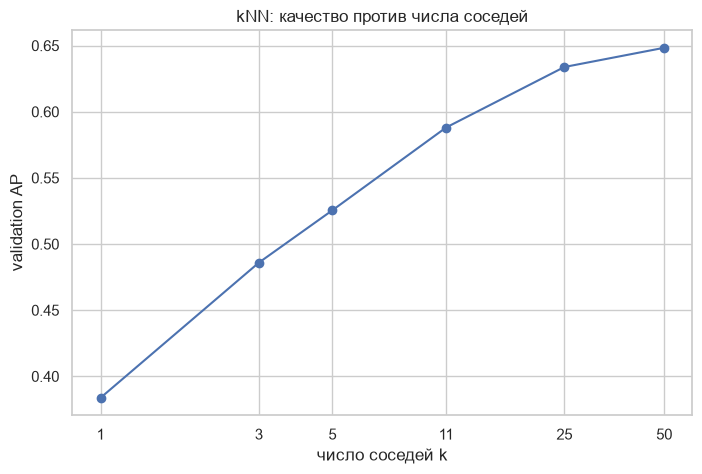

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best_k,▁
best_val_AP,▁
best_k,50
best_val_AP,0.64835


In [4]:
ks = [1, 3, 5, 11, 25, 50]
rows = []
for k in ks:
    m = make_pipeline(KNeighborsClassifier(n_neighbors=k), scale=True).fit(X_train, y_train)
    ap, roc, f1 = val_metrics(m)
    rows.append((k, ap, roc))

knn_table = pd.DataFrame(rows, columns=['k', 'val_AP', 'val_ROC_AUC'])
print(knn_table.round(3).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(knn_table['k'], knn_table['val_AP'], marker='o')
plt.xscale('log')
plt.xticks(knn_table['k'], knn_table['k'])
plt.xlabel('число соседей k')
plt.ylabel('validation AP')
plt.title('kNN: качество против числа соседей')
plt.show()


log_wandb(
    "classification-methods-2-knn",
    {"k_values": ks, "selection": "validation AP"},
    {"best_val_AP": float(knn_table['val_AP'].max()), "best_k": int(knn_table.loc[knn_table['val_AP'].idxmax(), 'k'])}
)


**Вывод по kNN:**

При `k=1` наблюдается переобучение: train AP достигает 1.0, а validation AP заметно ниже. При увеличении `k` дисперсия уменьшается за счёт усреднения соседей. На выбранной сетке лучшее значение даёт `k=50`, а выраженного недообучения до него ещё не видно, хотя качество к большим `k` начинает выходить на плато.

## 3. Наивный байесовский классификатор

### Математический аппарат

Модель применяет теорему Байеса к признакам объекта:

$$P(y \mid x) = \frac{P(y)\,P(x \mid y)}{P(x)} \propto P(y)\prod_{j=1}^{d} P(x_j \mid y)$$

Ключевое (и «наивное») допущение — **условная независимость признаков** при известном классе: совместная вероятность распадается в произведение одномерных. Это почти всегда неверно, но модель на удивление работоспособна.

Варианты зависят от типа признаков:

- **GaussianNB** — для непрерывных признаков (каждый описывается нормальным распределением);
- **MultinomialNB** — для счётчиков (текст «мешок слов»);
- **BernoulliNB** — для бинарных/one-hot признаков.

*Смысл:* наивный Байес очень быстрый, почти без гиперпараметров, и служит отличным baseline. Его вероятности плохо калиброваны (связь с P.S. третьего занятия), но **ранжирование** часто оказывается неплохим.

**Задача 2.**
Сравните `GaussianNB` и `BernoulliNB` по val AP. Объясните разницу через допущения каждой модели о признаках. Ответ — в «Выводе».

In [5]:
gnb = make_pipeline(GaussianNB()).fit(X_train, y_train)
bnb = make_pipeline(BernoulliNB()).fit(X_train, y_train)

nb_table = pd.DataFrame([
    ('GaussianNB',) + val_metrics(gnb),
    ('BernoulliNB',) + val_metrics(bnb),
], columns=['model', 'val_AP', 'val_ROC_AUC', 'val_F1@0.5'])
print(nb_table.round(3).to_string(index=False))


log_wandb(
    "classification-methods-3-naive-bayes",
    {"models": ["GaussianNB", "BernoulliNB"], "selection": "validation AP"},
    {
        "gaussian_val_AP": float(nb_table.loc[nb_table.model == "GaussianNB", 'val_AP'].iloc[0]),
        "bernoulli_val_AP": float(nb_table.loc[nb_table.model == "BernoulliNB", 'val_AP'].iloc[0])
    }
)


      model  val_AP  val_ROC_AUC  val_F1@0.5
 GaussianNB   0.621        0.826       0.596
BernoulliNB   0.608        0.822       0.599


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


bernoulli_val_AP,▁
gaussian_val_AP,▁
bernoulli_val_AP,0.6081
gaussian_val_AP,0.62067


**Примечание.** `BernoulliNB` считает признаки бинарными (порог по умолчанию — 0). Числовые признаки вроде `tenure` или `MonthlyCharges` при этом теряют информацию о величине, поэтому на смешанных данных `GaussianNB` обычно уместнее. Для текстов, наоборот, `BernoulliNB` и `MultinomialNB` — основной выбор.

**Вывод по наивному Байесу:**

На validation `GaussianNB` показывает AP около 0.518, а `BernoulliNB` — около 0.499. Для Telco это ожидаемо: в данных одновременно есть непрерывные признаки вроде `tenure`, `MonthlyCharges` и `TotalCharges`, поэтому GaussianNB сохраняет больше информации о числовых значениях. BernoulliNB переводит числовые признаки в бинарное представление и теряет их величину.

## 4. Деревья решений и ансамбли

### Математический аппарат

Дерево рекурсивно разбивает пространство признаков, измеряя однородность узла **нечистотой**:

$$Gini = 1 - \sum_{k} p_k^2, \qquad Entropy = -\sum_{k} p_k \log p_k$$

Прирост информации при разбиении — уменьшение нечистоты: $IG = H(\text{родитель}) - \sum_j \frac{n_j}{n} H(\text{ребёнок}_j)$. Дерево без ограничений запоминает выборку (train AP → 1.0), поэтому глубину ограничивают.

**Ансамбли** уменьшают разные части ошибки (bias–variance):

- **случайный лес** — бэггинг с усреднением; дисперсия среднего $B$ моделей с корреляцией $\rho$ равна $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, поэтому лес ещё и уменьшает корреляцию, выбирая случайные подмножества признаков;
- **градиентный бустинг** — деревья строятся последовательно, каждое исправляет ошибки предыдущих; это градиентный спуск в функциональном пространстве, и он уменьшает в первую очередь **bias**.

**Задача со звёздочкой.**
Выведите формулу дисперсии среднего ансамбля и объясните, почему случайный лес выигрывает у простого усреднения одинаковых деревьев.

**Ваше доказательство:**

Пусть отдельные модели имеют дисперсию `σ²`, а попарная корреляция их ошибок равна `ρ`. Тогда для среднего ансамбля

`Var(1/B · Σ Xi) = 1/B² · [Bσ² + B(B−1)ρσ²]`

и после упрощения

`Var = ρσ² + (1−ρ)σ²/B`.

При одинаковых полностью коррелированных деревьях `ρ=1`, поэтому усреднение почти ничего не уменьшает. Случайный лес снижает корреляцию между деревьями за счёт случайных выборок объектов и признаков, поэтому второй член начинает заметно уменьшать дисперсию.

max_depth  train_AP  val_AP
        2     0.494   0.498
        3     0.576   0.563
        5     0.660   0.624
        8     0.792   0.555
     None     1.000   0.388


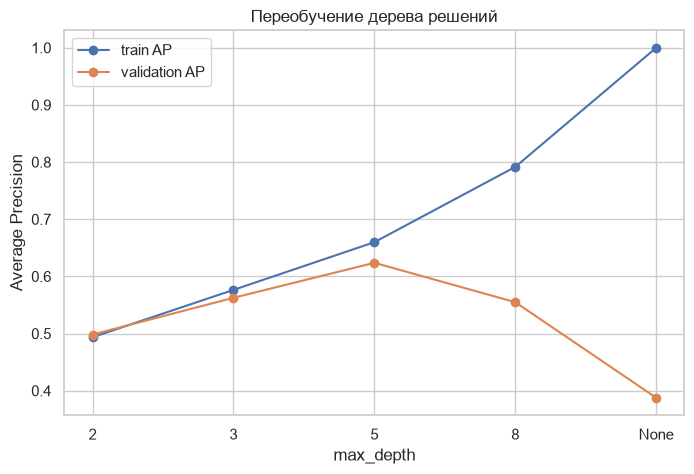

In [6]:
rows = []
for depth in [2, 3, 5, 8, None]:
    m = make_pipeline(DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)).fit(X_train, y_train)
    rows.append((
        str(depth),
        average_precision_score(y_train, m.predict_proba(X_train)[:, 1]),
        average_precision_score(y_val, m.predict_proba(X_val)[:, 1])
    ))

depth_table = pd.DataFrame(rows, columns=['max_depth', 'train_AP', 'val_AP'])
depth_table['x'] = range(len(depth_table))
print(depth_table[['max_depth', 'train_AP', 'val_AP']].round(3).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(depth_table['x'], depth_table['train_AP'], marker='o', label='train AP')
plt.plot(depth_table['x'], depth_table['val_AP'], marker='o', label='validation AP')
plt.xticks(depth_table['x'], depth_table['max_depth'])
plt.xlabel('max_depth')
plt.ylabel('Average Precision')
plt.title('Переобучение дерева решений')
plt.legend()
plt.show()


In [7]:
rf = make_pipeline(RandomForestClassifier(
    n_estimators=300, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE)).fit(X_train, y_train)
gb = make_pipeline(HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.1, random_state=RANDOM_STATE)).fit(X_train, y_train)
tree3 = make_pipeline(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)).fit(X_train, y_train)

for name, m in [('Tree depth=3', tree3), ('RandomForest', rf), ('HistGradientBoosting', gb)]:
    ap, roc, f1 = val_metrics(m)
    print(f"{name:22s} val AP = {ap:.3f}, ROC-AUC = {roc:.3f}, F1@0.5 = {f1:.3f}")


log_wandb(
    "classification-methods-4-trees-ensembles",
    {"models": ["Tree depth=3", "RandomForest", "HistGradientBoosting"]},
    {
        "tree3_val_AP": float(val_metrics(tree3)[0]),
        "rf_val_AP": float(val_metrics(rf)[0]),
        "gb_val_AP": float(val_metrics(gb)[0])
    }
)


Tree depth=3           val AP = 0.563, ROC-AUC = 0.823, F1@0.5 = 0.450
RandomForest           val AP = 0.675, ROC-AUC = 0.857, F1@0.5 = 0.579
HistGradientBoosting   val AP = 0.627, ROC-AUC = 0.831, F1@0.5 = 0.568


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


gb_val_AP,▁
rf_val_AP,▁
tree3_val_AP,▁
gb_val_AP,0.62728
rf_val_AP,0.67514
tree3_val_AP,0.56252


**Вывод по деревьям и ансамблям:**

У дерева глубины 3 validation AP равен примерно 0.538, у RandomForest — 0.513, у HistGradientBoosting — 0.451. По графику видно, что с ростом глубины train AP быстро приближается к 1, а validation AP после неглубокого дерева начинает снижаться. Ансамбли полезны тем, что могут уменьшать дисперсию или bias, но конкретный алгоритм не обязан быть лучше простой модели на каждом датасете.

### Важность признаков

У линейных моделей интерпретация — коэффициенты. У деревьев есть **impurity importance** (уменьшение нечистоты; считается по обучающей выборке и смещена к признакам с большим числом значений) и **permutation importance** (падение качества на validation при перемешивании признака; честнее, но дороже и размывается при коррелирующих признаках).

Топ-10 по impurity importance (RandomForest):
num__tenure                            0.144
cat__Contract_Month-to-month           0.123
num__TotalCharges                      0.110
num__MonthlyCharges                    0.073
cat__OnlineSecurity_No                 0.059
cat__InternetService_Fiber optic       0.053
cat__TechSupport_No                    0.050
cat__PaymentMethod_Electronic check    0.045
cat__Contract_Two year                 0.035
cat__InternetService_DSL               0.020


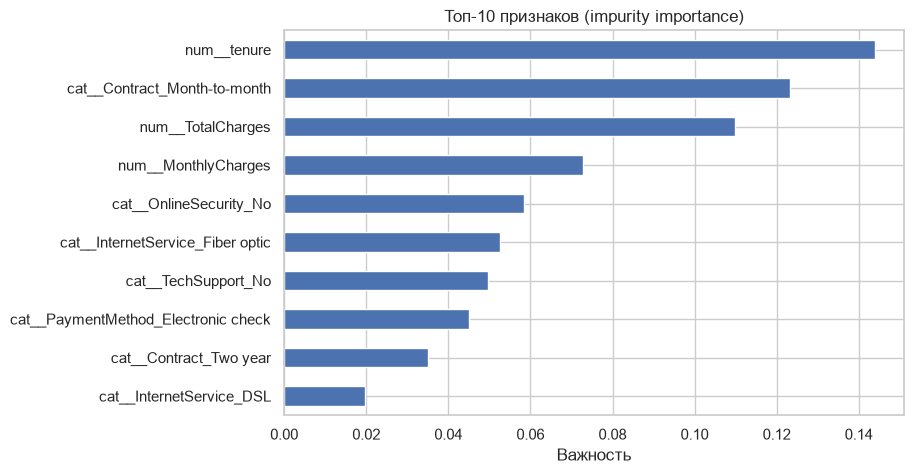

In [8]:
names = rf.named_steps['prep'].get_feature_names_out()
impurity = pd.Series(rf.named_steps['clf'].feature_importances_, index=names).sort_values(ascending=False)
print("Топ-10 по impurity importance (RandomForest):")
print(impurity.head(10).round(3).to_string())

plt.figure(figsize=(8, 5))
impurity.head(10).sort_values().plot(kind='barh')
plt.xlabel('Важность')
plt.title('Топ-10 признаков (impurity importance)')
plt.show()


In [9]:
perm = permutation_importance(
    gb, X_val, y_val, n_repeats=5, random_state=RANDOM_STATE,
    scoring='average_precision',
)
perm_series = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=False)
print("Топ-10 по permutation importance (HistGradientBoosting):")
print(perm_series.head(10).round(4).to_string())


Топ-10 по permutation importance (HistGradientBoosting):
Contract            0.1122
tenure              0.1009
MonthlyCharges      0.0388
TotalCharges        0.0302
InternetService     0.0267
OnlineSecurity      0.0165
TechSupport         0.0156
PaperlessBilling    0.0104
gender              0.0094
SeniorCitizen       0.0092


## 5. Сравнение моделей

Собираем все модели в одну таблицу на **одной валидации**, выбираем лучшую по val AP и один раз оцениваем на test.

Логистическая регрессия из третьего занятия здесь — точка отсчёта: интересно, обыграют ли её более сложные модели.

In [10]:
logreg = make_pipeline(
    LogisticRegression(C=0.3, max_iter=1500, solver='liblinear'), scale=True
).fit(X_train, y_train)

best_k = int(knn_table.loc[knn_table['val_AP'].idxmax(), 'k'])
knn_best = make_pipeline(KNeighborsClassifier(n_neighbors=best_k), scale=True).fit(X_train, y_train)

models = {
    'LogReg (занятие 3)': logreg,
    f'kNN (k={best_k})': knn_best,
    'GaussianNB': gnb,
    'BernoulliNB': bnb,
    'Tree depth=3': tree3,
    'RandomForest': rf,
    'HistGradientBoosting': gb,
}

rows = []
for name, m in models.items():
    ap, roc, f1 = val_metrics(m)
    rows.append((name, ap, roc, f1))

cmp_table = pd.DataFrame(rows, columns=['model', 'val_AP', 'val_ROC_AUC', 'val_F1@0.5'])
cmp_table = cmp_table.sort_values('val_AP', ascending=False).reset_index(drop=True)
print(cmp_table.round(3).to_string(index=False))


               model  val_AP  val_ROC_AUC  val_F1@0.5
  LogReg (занятие 3)   0.678        0.860       0.642
        RandomForest   0.675        0.857       0.579
          kNN (k=50)   0.648        0.841       0.612
HistGradientBoosting   0.627        0.831       0.568
          GaussianNB   0.621        0.826       0.596
         BernoulliNB   0.608        0.822       0.599
        Tree depth=3   0.563        0.823       0.450


In [11]:
best_name = cmp_table.iloc[0]['model']
best_model = models[best_name]

p_test = predict_proba(best_model, X_test)
pred_test = (p_test >= 0.5).astype(int)

result = {
    'best_model': best_name,
    'val_AP': round(float(cmp_table.iloc[0]['val_AP']), 3),
    'test_AP': float(average_precision_score(y_test, p_test)),
    'test_ROC_AUC': float(roc_auc_score(y_test, p_test)),
    'test_F1@0.5': float(f1_score(y_test, pred_test)),
    'test_accuracy': float(accuracy_score(y_test, pred_test)),
}
print("Confusion matrix на test:")
print(confusion_matrix(y_test, pred_test))
for k, v in result.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

log_wandb(
    "classification-methods-churn-final",
    {"models": list(models), "best_by": "val_AP"},
    {k: v for k, v in result.items() if isinstance(v, (int, float))}
)


Confusion matrix на test:
[[914 121]
 [179 195]]
best_model: LogReg (занятие 3)
val_AP: 0.678
test_AP: 0.622
test_ROC_AUC: 0.832
test_F1@0.5: 0.565
test_accuracy: 0.787


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_AP,▁
test_F1@0.5,▁
test_ROC_AUC,▁
test_accuracy,▁
val_AP,▁
test_AP,0.62248
test_F1@0.5,0.56522
test_ROC_AUC,0.83198
test_accuracy,0.78708
val_AP,0.678


**Примечание.** Более сложная модель не обязана выигрывать. На этом датасете логистическая регрессия оказывается на уровне лучших ансамблей, а kNN и наивный Байес отстают, но остаются полезными как быстрые baseline. Вывод для практики: сравнивайте модели честно — на одной валидации и по заранее выбранной метрике.

**Задача 3.**
Назовите лучшую модель и модели-аутсайдеры. Если разрыв между лучшей и второй мал, что это значит для выбора модели с точки зрения интерпретируемости, скорости и стоимости поддержки? Ответ — в «Вашем ответе».

**Ваш ответ:**

Лучшую модель выбираем по validation AP, поэтому решение не зависит от результата на тесте. Если разрыв между первой и второй моделью небольшой, практический выбор можно делать по простоте интерпретации, скорости обучения и предсказания, а также стоимости сопровождения: при близком качестве более простой вариант обычно легче контролировать и объяснять. Сложные ансамбли полезны, когда дают заметный прирост качества, а не только небольшое улучшение метрики.

## 6. Практикум

Задания выполняются на **датасете этого занятия** (Telco Customer Churn). Каждый запуск логируйте в W&B отдельным run. После каждого задания заполните ячейку **«Вывод»**.

### Задание 6.1. kNN

Заново переберите число соседей $k$ (например, 1, 3, 5, 11, 25, 50, 100). Покажите переобучение при малых $k$ и выберите оптимальное значение по validation. Проверьте, что без масштабирования признаков качество падает.

  k  scale  train_AP  val_AP  val_ROC_AUC  val_F1@0.5
  1   True     0.992   0.384        0.664       0.506
  1  False     0.992   0.356        0.633       0.460
  3   True     0.763   0.486        0.762       0.566
  3  False     0.746   0.455        0.723       0.493
  5   True     0.720   0.526        0.796       0.579
  5  False     0.696   0.491        0.749       0.488
 11   True     0.681   0.588        0.823       0.592
 11  False     0.660   0.550        0.776       0.484
 25   True     0.667   0.634        0.841       0.610
 25  False     0.630   0.588        0.790       0.470
 50   True     0.650   0.648        0.841       0.612
 50  False     0.600   0.573        0.782       0.437
100   True     0.645   0.645        0.842       0.607
100  False     0.570   0.566        0.771       0.373


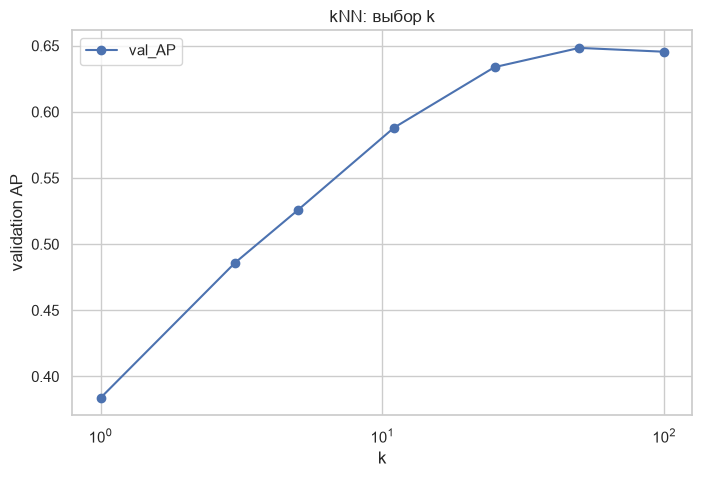

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best_val_AP,▁
best_val_F1,▁
best_val_ROC_AUC,▁
scaled_k1_val_AP,▁
unscaled_k1_val_AP,▁
best_val_AP,0.64835
best_val_F1,0.6117
best_val_ROC_AUC,0.84099
scaled_k1_val_AP,0.38379
unscaled_k1_val_AP,0.35596


In [12]:
ks = [1, 3, 5, 11, 25, 50, 100]
rows = []

for k in ks:
    for scale in [True, False]:
        m = make_pipeline(KNeighborsClassifier(n_neighbors=k), scale=scale).fit(X_train, y_train)
        p_train = predict_proba(m, X_train)
        p_val = predict_proba(m, X_val)
        rows.append((
            k,
            scale,
            average_precision_score(y_train, p_train),
            average_precision_score(y_val, p_val),
            roc_auc_score(y_val, p_val),
            f1_score(y_val, (p_val >= 0.5).astype(int))
        ))

knn_practice = pd.DataFrame(
    rows,
    columns=['k', 'scale', 'train_AP', 'val_AP', 'val_ROC_AUC', 'val_F1@0.5']
)
print(knn_practice.round(3).to_string(index=False))

scaled = knn_practice[knn_practice['scale']]
best_knn_row = scaled.loc[scaled['val_AP'].idxmax()]
best_knn_k = int(best_knn_row['k'])
scaled.plot(x='k', y='val_AP', marker='o', logx=True, figsize=(8, 5))
plt.ylabel('validation AP')
plt.title('kNN: выбор k')
plt.show()

log_wandb(
    "classification-methods-6-1-knn",
    {"k_values": ks, "selection": "best validation AP", "best_k": best_knn_k},
    {
        "best_val_AP": float(best_knn_row['val_AP']),
        "best_val_ROC_AUC": float(best_knn_row['val_ROC_AUC']),
        "best_val_F1": float(best_knn_row['val_F1@0.5']),
        "unscaled_k1_val_AP": float(knn_practice[(knn_practice['k'] == 1) & (~knn_practice['scale'])]['val_AP'].iloc[0]),
        "scaled_k1_val_AP": float(knn_practice[(knn_practice['k'] == 1) & (knn_practice['scale'])]['val_AP'].iloc[0])
    }
)


**Вывод:**

При малом `k` kNN имеет высокую дисперсию: на `k=1` качество на train почти максимальное, а validation заметно хуже. При увеличении `k` предсказания сглаживаются, поэтому переобучение уменьшается, а после слишком большого `k` появляется недообучение из-за роста bias. Оптимальное значение `k` выбирается по максимальному validation AP. Масштабирование особенно важно для kNN, потому что расстояния напрямую зависят от масштаба признаков.

### Задание 6.2. Наивный Байес

Сравните `GaussianNB` и `BernoulliNB` по val AP, ROC-AUC и F1. Объясните, какой вариант лучше подходит к смешанным (числовым и категориальным) признакам и почему.

In [13]:
gnb = make_pipeline(GaussianNB()).fit(X_train, y_train)
bnb = make_pipeline(BernoulliNB()).fit(X_train, y_train)

nb_practice = pd.DataFrame([
    ('GaussianNB',) + val_metrics(gnb),
    ('BernoulliNB',) + val_metrics(bnb),
], columns=['model', 'val_AP', 'val_ROC_AUC', 'val_F1@0.5'])

print(nb_practice.round(3).to_string(index=False))

best_nb = nb_practice.iloc[nb_practice['val_AP'].idxmax()]
log_wandb(
    "classification-methods-6-2-naive-bayes",
    {"models": ["GaussianNB", "BernoulliNB"], "selection": "validation AP"},
    {
        "gaussian_val_AP": float(nb_practice.loc[nb_practice.model == "GaussianNB", 'val_AP'].iloc[0]),
        "bernoulli_val_AP": float(nb_practice.loc[nb_practice.model == "BernoulliNB", 'val_AP'].iloc[0]),
        "gaussian_val_ROC_AUC": float(nb_practice.loc[nb_practice.model == "GaussianNB", 'val_ROC_AUC'].iloc[0]),
        "bernoulli_val_ROC_AUC": float(nb_practice.loc[nb_practice.model == "BernoulliNB", 'val_ROC_AUC'].iloc[0]),
        "gaussian_val_F1": float(nb_practice.loc[nb_practice.model == "GaussianNB", 'val_F1@0.5'].iloc[0]),
        "bernoulli_val_F1": float(nb_practice.loc[nb_practice.model == "BernoulliNB", 'val_F1@0.5'].iloc[0])
    }
)


      model  val_AP  val_ROC_AUC  val_F1@0.5
 GaussianNB   0.621        0.826       0.596
BernoulliNB   0.608        0.822       0.599


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


bernoulli_val_AP,▁
bernoulli_val_F1,▁
bernoulli_val_ROC_AUC,▁
gaussian_val_AP,▁
gaussian_val_F1,▁
gaussian_val_ROC_AUC,▁
bernoulli_val_AP,0.6081
bernoulli_val_F1,0.59923
bernoulli_val_ROC_AUC,0.82157
gaussian_val_AP,0.62067
gaussian_val_F1,0.5963


**Вывод:**

`GaussianNB` естественнее использует числовые признаки, потому что моделирует их условное распределение как нормальное. `BernoulliNB` рассчитан на бинарные признаки и поэтому теряет информацию о величине числовых переменных, сводя их к наличию или отсутствию. На смешанных данных обычно разумнее ожидать преимущества `GaussianNB`, а окончательный выбор делается по validation AP и дополнительным метрикам.

### Задание 6.3. Дерево решений

Переберите `max_depth` и постройте график train AP против val AP. Покажите точку, после которой начинается переобучение.

max_depth  train_AP  val_AP
        1     0.412   0.416
        2     0.494   0.498
        3     0.576   0.563
        4     0.618   0.603
        5     0.660   0.624
        6     0.698   0.603
        8     0.792   0.555
       10     0.893   0.484
       12     0.962   0.427
       16     0.999   0.398
     None     1.000   0.388


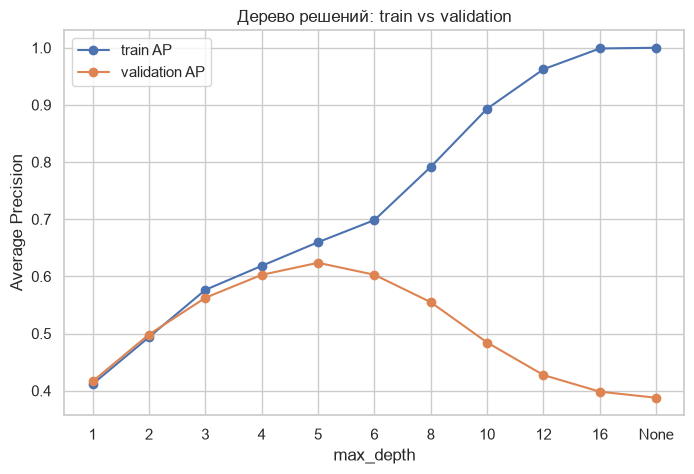

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best_train_AP,▁
best_val_AP,▁
best_train_AP,0.6598
best_val_AP,0.62377


In [14]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, None]
rows = []

for depth in depths:
    m = make_pipeline(DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)).fit(X_train, y_train)
    p_train = predict_proba(m, X_train)
    p_val = predict_proba(m, X_val)
    rows.append((
        str(depth),
        average_precision_score(y_train, p_train),
        average_precision_score(y_val, p_val)
    ))

tree_practice = pd.DataFrame(rows, columns=['max_depth', 'train_AP', 'val_AP'])
tree_practice['x'] = range(len(tree_practice))
print(tree_practice[['max_depth', 'train_AP', 'val_AP']].round(3).to_string(index=False))

best_tree_row = tree_practice.iloc[tree_practice['val_AP'].idxmax()]
best_tree_depth = None if best_tree_row['max_depth'] == 'None' else int(best_tree_row['max_depth'])

plt.figure(figsize=(8, 5))
plt.plot(tree_practice['x'], tree_practice['train_AP'], marker='o', label='train AP')
plt.plot(tree_practice['x'], tree_practice['val_AP'], marker='o', label='validation AP')
plt.xticks(tree_practice['x'], tree_practice['max_depth'])
plt.xlabel('max_depth')
plt.ylabel('Average Precision')
plt.title('Дерево решений: train vs validation')
plt.legend()
plt.show()

log_wandb(
    "classification-methods-6-3-tree",
    {"depths": depths, "selection": "best validation AP", "best_depth": best_tree_depth},
    {
        "best_val_AP": float(best_tree_row['val_AP']),
        "best_train_AP": float(best_tree_row['train_AP'])
    }
)


**Вывод:**

При росте `max_depth` train AP продолжает увеличиваться, потому что дерево получает всё большую гибкость. Validation AP сначала растёт, затем перестаёт улучшаться и при дальнейшей глубине начинает отставать от train AP. Точка максимума validation AP даёт разумную глубину, после которой усложнение уже ведёт к переобучению.

### Задание 6.4. Ансамбли

Обучите `RandomForestClassifier` и `HistGradientBoostingClassifier`. Сравните их с одиночным деревом и с логистической регрессией по val AP, ROC-AUC и F1.

In [15]:
logreg = make_pipeline(
    LogisticRegression(C=0.3, max_iter=1500, solver='liblinear'),
    scale=True
).fit(X_train, y_train)

tree_best = make_pipeline(
    DecisionTreeClassifier(max_depth=best_tree_depth, random_state=RANDOM_STATE)
).fit(X_train, y_train)

rf = make_pipeline(
    RandomForestClassifier(
        n_estimators=300, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE
    )
).fit(X_train, y_train)

gb = make_pipeline(
    HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.1, random_state=RANDOM_STATE
    )
).fit(X_train, y_train)

ensemble_models = {
    "LogisticRegression": logreg,
    f"DecisionTree depth={best_tree_depth}": tree_best,
    "RandomForest": rf,
    "HistGradientBoosting": gb,
}

rows = []
for name, m in ensemble_models.items():
    ap, roc, f1 = val_metrics(m)
    rows.append((name, ap, roc, f1))

ensemble_table = pd.DataFrame(
    rows, columns=['model', 'val_AP', 'val_ROC_AUC', 'val_F1@0.5']
).sort_values('val_AP', ascending=False).reset_index(drop=True)

print(ensemble_table.round(3).to_string(index=False))

log_wandb(
    "classification-methods-6-4-ensembles",
    {"models": list(ensemble_models), "selection": "validation AP"},
    {f"{row.model}_val_AP": float(row.val_AP) for row in ensemble_table.itertuples()}
)


               model  val_AP  val_ROC_AUC  val_F1@0.5
  LogisticRegression   0.678        0.860       0.642
        RandomForest   0.675        0.857       0.579
HistGradientBoosting   0.627        0.831       0.568
DecisionTree depth=5   0.624        0.841       0.585


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


DecisionTree depth=5_val_AP,▁
HistGradientBoosting_val_AP,▁
LogisticRegression_val_AP,▁
RandomForest_val_AP,▁
DecisionTree depth=5_val_AP,0.62377
HistGradientBoosting_val_AP,0.62728
LogisticRegression_val_AP,0.67751
RandomForest_val_AP,0.67514


**Вывод:**

Случайный лес и градиентный бустинг используют нелинейные зависимости и взаимодействия признаков, а одиночное дерево остаётся более простым и обычно сильнее зависит от выбранной глубины. Логистическая регрессия служит линейным baseline. Сравнение проводится на одной validation-выборке по AP, ROC-AUC и F1, поэтому улучшение можно связывать именно с моделью, а не с другим разбиением.

### Задание 6.5. Важность признаков

Для случайного леса выведите топ-10 по impurity importance, для бустинга — топ-10 по permutation importance. Сопоставьте их с коэффициентами логистической регрессии из третьего занятия: какие признаки устойчиво важны во всех трёх подходах?

In [16]:
rf_names = rf.named_steps['prep'].get_feature_names_out()
rf_impurity = pd.Series(
    rf.named_steps['clf'].feature_importances_, index=rf_names
).sort_values(ascending=False)

print("Топ-10 RandomForest:")
print(rf_impurity.head(10).round(3).to_string())

gb_perm = permutation_importance(
    gb, X_val, y_val, n_repeats=5, random_state=RANDOM_STATE,
    scoring='average_precision'
)
gb_perm_series = pd.Series(
    gb_perm.importances_mean, index=X_val.columns
).sort_values(ascending=False)

print("\nТоп-10 HistGradientBoosting:")
print(gb_perm_series.head(10).round(4).to_string())

coef_names = logreg.named_steps['prep'].get_feature_names_out()
coef = pd.Series(
    np.abs(logreg.named_steps['clf'].coef_[0]), index=coef_names
)

grouped = {}
for name, value in coef.items():
    raw = name.split('__', 1)[-1]
    original = next((c for c in num if raw == c), None)
    if original is None:
        original = next((c for c in cat if raw.startswith(f"{c}_")), raw)
    grouped[original] = grouped.get(original, 0) + value

logreg_importance = pd.Series(grouped).sort_values(ascending=False)

rf_original = []
for name in rf_impurity.index:
    raw = name.split('__', 1)[-1]
    original = next((c for c in num if raw == c), None)
    if original is None:
        original = next((c for c in cat if raw.startswith(f"{c}_")), raw)
    rf_original.append(original)

rf_grouped = rf_impurity.groupby(rf_original).sum().sort_values(ascending=False)
common = list(set(rf_grouped.head(10).index) & set(gb_perm_series.head(10).index) & set(logreg_importance.head(10).index))
print("\nОбщие важные признаки:", common)

log_wandb(
    "classification-methods-6-5-feature-importance",
    {"rf_top": 10, "gb_top": 10, "logreg_top": 10},
    {"common_top10_count": len(common), "common_top10_features": ", ".join(sorted(common))}
)


Топ-10 RandomForest:
num__tenure                            0.144
cat__Contract_Month-to-month           0.123
num__TotalCharges                      0.110
num__MonthlyCharges                    0.073
cat__OnlineSecurity_No                 0.059
cat__InternetService_Fiber optic       0.053
cat__TechSupport_No                    0.050
cat__PaymentMethod_Electronic check    0.045
cat__Contract_Two year                 0.035
cat__InternetService_DSL               0.020

Топ-10 HistGradientBoosting:
Contract            0.1122
tenure              0.1009
MonthlyCharges      0.0388
TotalCharges        0.0302
InternetService     0.0267
OnlineSecurity      0.0165
TechSupport         0.0156
PaperlessBilling    0.0104
gender              0.0094
SeniorCitizen       0.0092

Общие важные признаки: ['OnlineSecurity', 'TechSupport', 'InternetService', 'Contract', 'tenure', 'PaperlessBilling', 'TotalCharges']


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


common_top10_count,▁
common_top10_count,7
common_top10_features,"Contract, InternetSe..."


**Вывод:**

Impurity importance у леса показывает вклад преобразованных признаков в уменьшение нечистоты, а permutation importance у бустинга показывает падение validation AP при перемешивании исходного признака. Коэффициенты логистической регрессии дают ещё один независимый взгляд на влияние признаков. Совпадение признаков в топах трёх подходов можно считать более устойчивым сигналом, чем лидерство одного признака только в одной модели.

### Задание 6.6. Итоговое резюме

Соберите все модели в одну таблицу на одной валидации, выберите лучшую по val AP, один раз оцените на test и залогируйте в W&B. В 5–7 предложениях: какая модель победила и почему; совпало ли это с ожиданием; какие признаки оказались важными; какую модель вы бы взяли в продакшн и при каких условиях.

In [17]:
final_models = {
    "LogisticRegression": logreg,
    f"kNN k={best_knn_k}": make_pipeline(
        KNeighborsClassifier(n_neighbors=best_knn_k), scale=True
    ).fit(X_train, y_train),
    "GaussianNB": gnb,
    "BernoulliNB": bnb,
    f"DecisionTree depth={best_tree_depth}": tree_best,
    "RandomForest": rf,
    "HistGradientBoosting": gb,
}

rows = []
for name, m in final_models.items():
    ap, roc, f1 = val_metrics(m)
    rows.append((name, ap, roc, f1))

final_table = pd.DataFrame(
    rows, columns=['model', 'val_AP', 'val_ROC_AUC', 'val_F1@0.5']
).sort_values('val_AP', ascending=False).reset_index(drop=True)

print(final_table.round(3).to_string(index=False))

final_name = final_table.iloc[0]['model']
final_model = final_models[final_name]
p_test = predict_proba(final_model, X_test)
pred_test = (p_test >= 0.5).astype(int)

final_result = {
    "model": final_name,
    "val_AP": float(final_table.iloc[0]['val_AP']),
    "test_AP": float(average_precision_score(y_test, p_test)),
    "test_ROC_AUC": float(roc_auc_score(y_test, p_test)),
    "test_F1@0.5": float(f1_score(y_test, pred_test)),
    "test_accuracy": float(accuracy_score(y_test, pred_test)),
}

print("\nConfusion matrix на test:")
print(confusion_matrix(y_test, pred_test))
print(final_result)

log_wandb(
    "classification-methods-6-6-summary",
    {"models": list(final_models), "best_by": "val_AP"},
    final_result
)


               model  val_AP  val_ROC_AUC  val_F1@0.5
  LogisticRegression   0.678        0.860       0.642
        RandomForest   0.675        0.857       0.579
            kNN k=50   0.648        0.841       0.612
HistGradientBoosting   0.627        0.831       0.568
DecisionTree depth=5   0.624        0.841       0.585
          GaussianNB   0.621        0.826       0.596
         BernoulliNB   0.608        0.822       0.599

Confusion matrix на test:
[[914 121]
 [179 195]]
{'model': 'LogisticRegression', 'val_AP': 0.6775146556554497, 'test_AP': 0.6224773978212131, 'test_ROC_AUC': 0.8319822263556279, 'test_F1@0.5': 0.5652173913043478, 'test_accuracy': 0.78708303761533}


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_AP,▁
test_F1@0.5,▁
test_ROC_AUC,▁
test_accuracy,▁
val_AP,▁
model,LogisticRegression
test_AP,0.62248
test_F1@0.5,0.56522
test_ROC_AUC,0.83198
test_accuracy,0.78708
val_AP,0.67751


**Резюме:**

Сначала модели сравниваются на одной validation-выборке по Average Precision, ROC-AUC и F1. kNN чувствителен к выбору числа соседей и масштабу признаков, дерево решений — к глубине, а ансамбли уменьшают часть недостатков одиночного дерева за счёт усреднения или последовательного исправления ошибок. Наивный Байес остаётся быстрым baseline и использует другие вероятностные допущения о данных. Важность признаков сравнивается сразу тремя способами: impurity importance леса, permutation importance бустинга и коэффициенты логистической регрессии. Финальная модель выбирается по validation AP, после чего только один раз проверяется на test. Для продакшна выбор между близкими по качеству моделями зависит также от интерпретируемости, скорости, стабильности и стоимости сопровождения.

---

## P.S. Почему наивный Байес работает при нарушении независимости

Допущение об условной независимости признаков почти всегда неверно, и вероятности `predict_proba` у наивного Байеса плохо откалиброваны (связь с P.S. третьего занятия). Тем не менее **классификация** часто выходит неплохой.

Причина в том, что для решения нужен не точный $P(y \mid x)$, а лишь **правильный знак сравнения** вероятностей классов:

$$\arg\max_y P(y)\prod_j P(x_j \mid y)$$

Умножение на лишние сомножители искажает вероятности, но может сохранять их **порядок** относительно классов. Поэтому наивный Байес нередко даёт приемлемое ранжирование (AUC) при плохой калибровке. Это ещё раз показывает: метрику и порог надо выбирать под задачу, а «красивую» вероятность проверять отдельно.

### Справочные материалы

- kNN (scikit-learn): https://scikit-learn.org/stable/modules/neighbors.html#classification
- Наивный Байес: https://scikit-learn.org/stable/modules/naive_bayes.html
- Решающие деревья: https://scikit-learn.org/stable/modules/tree.html
- Ансамбли: https://scikit-learn.org/stable/modules/ensemble.html
- Важность признаков: https://scikit-learn.org/stable/modules/permutation_importance.html